<a href="https://colab.research.google.com/github/mic006016/yolo-pedestrian-safety/blob/main/YOLOv5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.__version__)

2.11.0+cu128


In [ ]:
# GPU 사용 체크
is_cuda = False
if torch.cuda.is_available():
  is_cuda = True

print("CUDA 사용 가능 여부:", torch.cuda.is_available())

CUDA 사용 가능 여부: True


Dataset 구축

In [ ]:
# PASCAL VOC Dataset 다운로드 및 압축 풀기
!pip install gdown
!gdown 1w_WBizEt2e_u6T9iY-hkwA-fIVsJktbB
!tar -xf VOCtrainval_11-May-2012.tar
!rm VOCtrainval_11-May-2012.tar

Downloading...
From (original): https://drive.google.com/uc?id=1w_WBizEt2e_u6T9iY-hkwA-fIVsJktbB
From (redirected): https://drive.google.com/uc?id=1w_WBizEt2e_u6T9iY-hkwA-fIVsJktbB&confirm=t&uuid=d1ef0977-8b10-4ff7-86bf-1d17a6a0812b
To: /content/VOCtrainval_11-May-2012.tar
100% 2.00G/2.00G [00:16<00:00, 118MB/s]


In [ ]:
# Pascal VOC 데이터셋의 클래스 리스트가 있는 파일 생성
classes = ["aeroplane\n", "bicycle\n", "bird\n", "boat\n", "bottle\n",
           "bus\n", "car\n", "cat\n", "chair\n", "cow\n", "diningtable\n",
           "dog\n", "horse\n", "motorbike\n", "person\n", "pottedplant\n",
           "sheep\n", "sofa\n", "train\n", "tvmonitor"]
with open("vocnames.txt", 'w') as f:
    f.writelines(classes)

In [ ]:
# convert2Yolo 저장소를 활용해 xml 파일을 txt 파일로 변환
!git clone https://github.com/ssaru/convert2Yolo.git
!cd convert2Yolo && python3 example.py --datasets VOC \
--img_path ../VOCdevkit/VOC2012/JPEGImages/ \
--label ../VOCdevkit/VOC2012/Annotations/ \
--convert_output_path ../VOCdevkit/VOC2012/JPEGImages/ \
--img_type ".jpg" \
--manifest_path ../ \
--cls_list_file ../vocnames.txt

fatal: destination path 'convert2Yolo' already exists and is not an empty directory.

VOC Parsing:   |████████████████████████████████████████| 100.0% (17125/17125)  Complete


YOLO Generating:|████████████████████████████████████████| 100.0% (17125/17125)  Complete


YOLO Saving:   |████████████████████████████████████████| 100.0% (17125/17125)  Complete



In [ ]:
# 훈련 데이터와 검증 데이터 분리
import os
import shutil
from tqdm import tqdm
data_root = "/content/VOCData"
val_root = os.path.join(data_root, "val")
train_root = os.path.join(data_root, "train")
os.makedirs(val_root, exist_ok=True)
os.makedirs(train_root, exist_ok=True)

with open("/content/manifest.txt") as f:
    files = f.readlines()

for idx, img_path in tqdm(enumerate(files)):
    img_src = img_path.split('\n')[0]
    txt_src = os.path.splitext(img_src)[0] + ".txt"
    img_name = os.path.split(img_src)[-1]
    text_name = os.path.split(txt_src)[-1]
    if idx % 10 < 3:
        img_dst = os.path.join(val_root, img_name)
        text_dst = os.path.join(val_root, text_name)
    else:
        img_dst = os.path.join(train_root, img_name)
        text_dst = os.path.join(train_root, text_name)
    shutil.copy2(img_src, img_dst)
    shutil.copy2(txt_src, text_dst)

17125it [00:05, 2994.82it/s]


YOLOv5 환경 구축

In [ ]:
# YOLOv5 최신 버전 클론
!git clone https://github.com/ultralytics/yolov5

# 폴더 이동 및 의존성 설치
%cd yolov5
!pip install -r requirements.txt

fatal: destination path 'yolov5' already exists and is not an empty directory.
/content/yolov5


detect: weights=['yolov5s.pt'], source=data/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-497-gfe219ed8 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/2 /content/yolov5/data/images/bus.jpg: 640x480 4 persons, 1 bus, 47.2ms
image 2/2 /content/yolov5/data/images/zidane.jpg: 384x640 2 persons, 2 ties, 48.8ms
Speed: 0.5ms pre-process, 48.0ms inference, 31.9ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp2


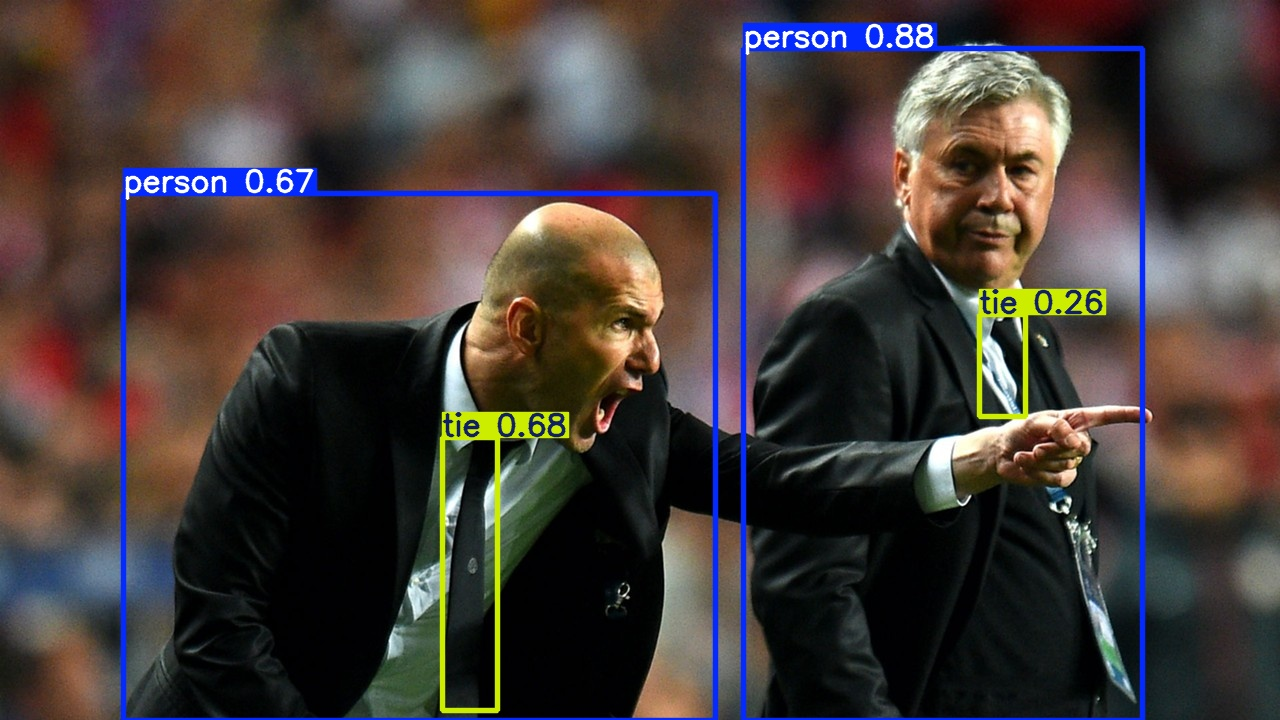

In [ ]:
# 테스트
!python detect.py --weights yolov5s.pt --img 640 --conf 0.25 --source data/images
import cv2
from google.colab.patches import cv2_imshow
cv2_imshow(cv2.imread('runs/detect/exp/zidane.jpg'))

In [ ]:
# 폴더 경로를 입력하여 VOC 데이터셋을 훈련하기 위한 yaml파일 제작
text_lines = '''
train:
  - /content/VOCData/train
val:
  - /content/VOCData/val

# Classes
names:
  0: aeroplane
  1: bicycle
  2: bird
  3: boat
  4: bottle
  5: bus
  6: car
  7: cat
  8: chair
  9: cow
  10: diningtable
  11: dog
  12: horse
  13: motorbike
  14: person
  15: pottedplant
  16: sheep
  17: sofa
  18: train
  19: tvmonitor
'''
with open("/content/yolov5/vocdata.yaml", 'w') as f:
    f.write(text_lines)

In [ ]:
!pwd

/content/yolov5


In [ ]:
# 훈련 수행
!python train.py --img 480 --batch 16 --epochs 20 --data vocdata.yaml --weights yolov5s.pt --cache

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  with torch.cuda.amp.autocast(amp):
      16/19      3.71G    0.03577    0.02913    0.01242         69        480:  70% 524/750 [00:40<00:17, 13.20it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      16/19      3.71G    0.03577    0.02913    0.01241         81        480:  70% 526/750 [00:40<00:16, 13.42it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      16/19      3.71G    0.03578    0.02912    0.01241         76        480:  70% 526/750 [00:40<00:16, 13.42it/s]/content/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      16/

In [ ]:
# weight 파일 다운로드
from google.colab import files
files.download('/content/yolov5/runs/train/exp/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>